In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir data

In [3]:
!cd data
!mkdir train
!mkdir test

In [4]:
!unzip -q "/content/drive/MyDrive/test.zip" -d "/content/test"

In [5]:
!unzip -q "/content/drive/MyDrive/train.zip" -d "/content/train"

In [6]:
import os
import shutil

source_dir = "/content/train/train"

cats = "/content/train/cats"
dogs = "/content/train/dogs"

os.makedirs(cats, exist_ok = True)
os.makedirs(dogs, exist_ok = True)

for filename in os.listdir(source_dir):
  source_file_path = os.path.join(source_dir, filename) #this makes full path of each jpg file

  if filename.startswith('cat'):
    shutil.move(source_file_path, os.path.join(cats,filename))
  elif filename.startswith('dog'):
    shutil.move(source_file_path, os.path.join(dogs,filename))


In [7]:
shutil.rmtree('/content/train/train')

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

train_dir = '/content/train' # sees dogs and cats folders as classes

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 32,
    class_mode = 'binary',
    subset = 'training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 32,
    class_mode = 'binary',
    subset = 'validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [9]:
'ok'

'ok'

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor = 'val_accuracy',
    patience = 7,
    restore_best_weights = True
)

lr_decay = ReduceLROnPlateau(
    monitor = 'val_accuracy',
    patience = 3,
    factor = 0.5,
    min_lr = 0.00001
)

checkpoint = ModelCheckpoint(
    filepath = '/content/drive/MyDrive/cnn_assignment_5.keras',
    monitor = 'val_accuracy',
    save_best_only = True,
    verbose = 1
)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

model = Sequential()

# layer 1
model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# layer 2
model.add(Conv2D(64, (3,3), activation = 'relu'))  #increasing filers as we go deeper
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# layer 3
model.add(Conv2D(128, (3,3), activation = 'relu'))
model.add(BatchNormalization())

model.add(Flatten()) #converting 2d images to 1d list

model.add(Dense(512, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    75,760,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,920,065 (289.61 MB)

 Trainable params: 75,919,617 (289.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
model.compile(
    loss = 'binary_crossentropy', # categorical crossentropy is not suitable here
    optimizer = 'sgd',            #intellipaat specified optimizer
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs = 50,
    validation_data = validation_generator,
    callbacks = [early_stop, lr_decay, checkpoint]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5992 - loss: 0.8487
Epoch 1: val_accuracy improved from None to 0.68400, saving model to /content/drive/MyDrive/cnn_assignment_5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_assignment_5.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 300ms/step - accuracy: 0.6295 - loss: 0.7003 - val_accuracy: 0.6840 - val_loss: 0.5900 - learning_rate: 0.0100
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6899 - loss: 0.5854
Epoch 2: val_accuracy did not improve from 0.68400
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 280ms/step - accuracy: 0.6893 - loss: 0.5826 - val_accuracy: 0.5430 - val_loss: 0.8364 - learning_rate: 0.0100
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7155 - loss: 0.5576
Epoch 3: val_accuracy did not improve from 0.68400
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.7115 - loss: 0.5568 - val_accuracy: 0.6186 - val_loss: 0.6286 - learning_rate: 0.0100
Epo

In [2]:
# here, after training for two hours, runtime disconnected and i ran out of daily free GPU time(same happened yesterday)
# but the model is saved in the drive today, and its good model with training and validation accuracies at 85%

In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

amodel = load_model('/content/drive/MyDrive/cnn_assignment_5.keras')

def predict_img(file_path):
  img = image.load_img(file_path, target_size = (150,150))
  plt.imshow(img)
  plt.axis('off')
  plt.show()
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis = 0)
  img_array = img_array / 255.0
  prediction = amodel.predict(img_array)

  if prediction[0][0] > 0.50:
    print("Dog 🐶 \t Confidence:",prediction[0][0])
  else:
    print("Cat 😼 \t Confidence:",prediction[0][0])

saved_model_path = '/content/drive/MyDrive/cnn_assignment_5.keras'

def predict_batch(folder_path, model_path):
  smodel = load_model(model_path)
  images = [f for f in os.listdir(folder_path) if f.lower().endswith(['.jpg', 'jpeg', '.png'])]

  for img_name in images:
    img_path = os.path.join(folder_path, img_name)

    img = image.load_img(img_path, target_size = (150,150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    img_array = img_array/255.0

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.50:
      print("Dog 🐶 \t Confidence:",prediction[0][0])
    else:
      print("Cat 😼 \t Confidence:",prediction[0][0])

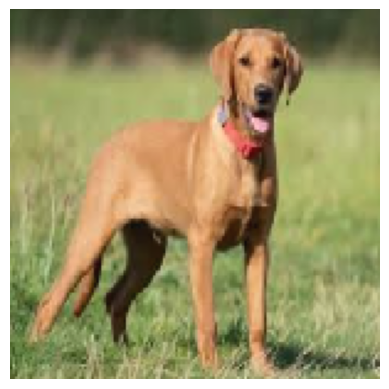

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
Dog 🐶 	 Confidence: 0.99522877


In [17]:
predict_img('/content/Screenshot 2026-04-16 122439.png')

In [18]:
# testing 10 images from the test set

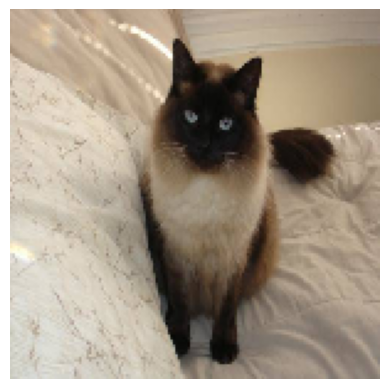

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Cat 😼 	 Confidence: 0.18741137


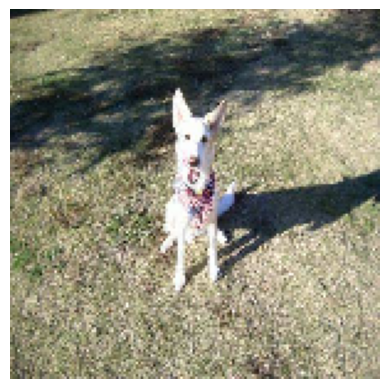

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Dog 🐶 	 Confidence: 0.9923564


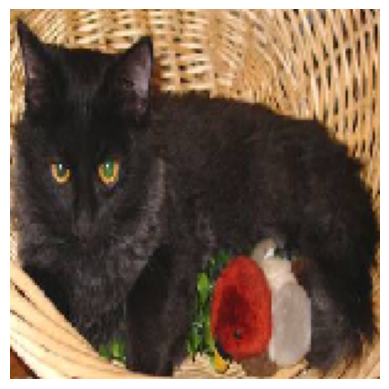

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Cat 😼 	 Confidence: 0.085049905


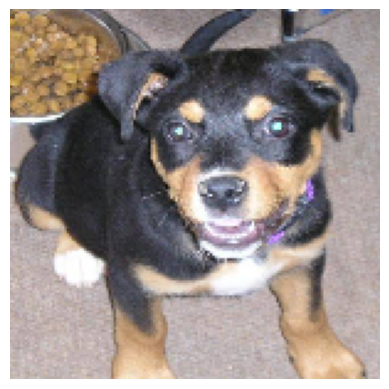

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Dog 🐶 	 Confidence: 0.9723331


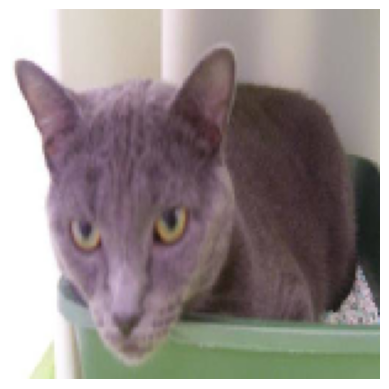

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Cat 😼 	 Confidence: 0.022055846


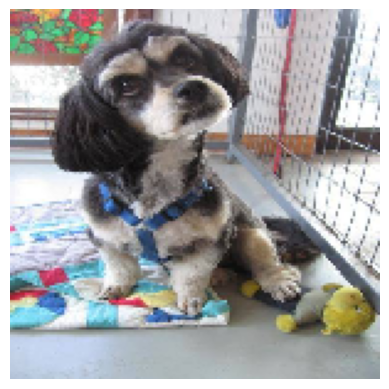

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Dog 🐶 	 Confidence: 0.90679634


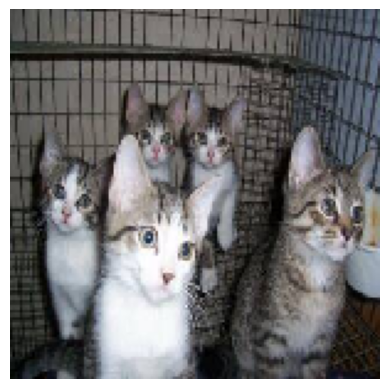

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Cat 😼 	 Confidence: 0.0009766443


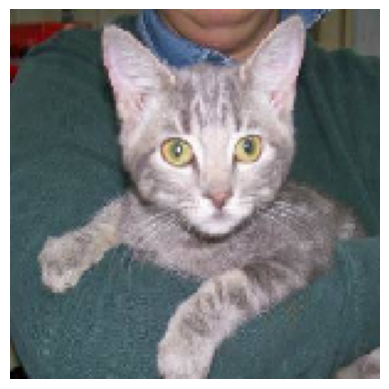

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Cat 😼 	 Confidence: 0.0050975564


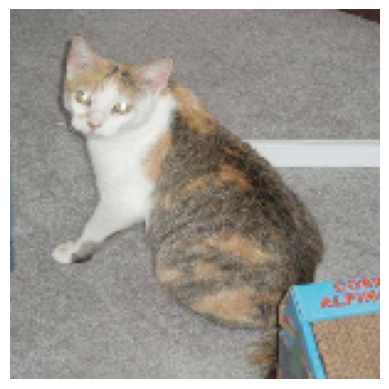

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Cat 😼 	 Confidence: 0.01833062


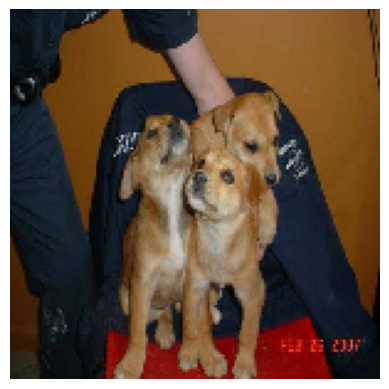

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Dog 🐶 	 Confidence: 0.96212685


In [21]:
import os
folder_path = '/content/test_10_images'
images = [f for f in os.listdir(folder_path)]
for img_name in images:
    img_path = os.path.join(folder_path, img_name)

    img = image.load_img(img_path, target_size = (150,150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    img_array = img_array/255.0

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    prediction = amodel.predict(img_array)

    if prediction[0][0] > 0.50:
      print("Dog 🐶 \t Confidence:",prediction[0][0])
    else:
      print("Cat 😼 \t Confidence:",prediction[0][0])